{'topic': '莲花', 'poem': '《咏莲》\n玉立亭亭出碧波，中通外直自婆娑。\n浊泥不染真君子，一脉清香万古歌。\n\n注：我的诗以莲花为咏诵对象，通过“玉立亭亭”、“中通外直”等意象展现其清雅高洁之姿。后两句以“浊泥不染”点睛，赞颂其超脱尘俗的君子品格，尾句“一脉清香万古歌”更将莲之精神升华为永恒的文化符号，暗合周敦颐《爱莲说》的千古意境。', 'ci_poem': '《行香子·莲》\n玉立亭亭，翠盖盈盈。立清波、素靥含冰。中通外直，不蔓枝横。任雨犹劲，风犹傲，暑犹清。\n心远尘萦，独濯沧浪。问濂溪、何故钟情？出泥不染，其质澄明。伴鹭同洁，云同逸，月同馨。\n\n注：我的仿写以周邦彦婉约词风为宗，通过“玉立亭亭”“翠盖盈盈”等意象勾勒莲之清姿。化用周敦颐《爱莲说》典故，以“中通外直”“出泥不染”双关君子品格。结句“伴鹭同洁”三叠，既合词律又暗含天人合一之境，展现莲在风雨暑浊中卓然自守的品格。', 'joke': '这里有几个关于莲花的笑话，希望你能喜欢：\n\n**1. 藕断丝连**\n老师问：“谁能解释‘藕断丝连’这个成语？”\n小明举手回答：“我知道！就是莲花和藕离婚了，但还一直有联系。”\n\n**2. 莲花为什么这么淡定**\n为什么莲花从来不焦虑？\n因为它每天都在水上“漂”，早就学会了“躺平”。\n\n**3. 莲花的职业**\n莲花最适合做什么工作？\n答案是——客服。因为它总是“莲”声细语，而且不管别人怎么喷，它都出淤泥而不染。\n\n**4. 荷花和荷叶吵架**\n荷花对荷叶说：“你能不能别老撑着一把破伞在我旁边晃？”\n荷叶委屈地说：“我这不是怕你晒黑嘛，毕竟你是靠脸吃饭的。”\n荷花冷笑：“拉倒吧，我靠脸？我明明是靠莲蓬头吃饭的。”\n\n**5. 莲花去面试**\n莲花去面试，面试官问：“你最大的缺点是什么？”\n莲花想了想说：“我太爱干净了，脏东西根本近不了我的身。”\n面试官：“那挺好的啊。”\n莲花叹气：“问题是，我连污水都嫌弃，结果HR说我不接地气。”\n\n**6. 猜谜式笑话**\n问：什么样的花最“佛系”？\n答：莲花。因为它天天坐在水里“打坐”，还动不动就“开悟”（开花）。\n\n🌺 希望这些笑话能让你会心一笑！'}


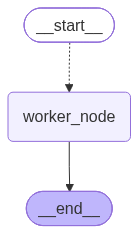

In [1]:
from typing import TypedDict,Literal,Sequence
from wsgiref.util import request_uri
from IPython.display import display
from IPython.core.debugger import prompt
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)

CONTENT_TYPES = ["poem","joke","ci_poem"]
model=ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":{
        "type":"disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic:str
    poem:str
    ci_poem:str
    joke:str
class workerState(TypedDict):
    content_type:Literal["poem","joke","ci_poem"]
    prompt:str
class inputState(TypedDict):
    topic:str
class outputState(TypedDict):
    poem:str
    ci_poem:str
    joke:str
def worker_node(state:workerState)->outputState:
    content_type=state["content_type"]
    prompt=state["prompt"]
    content=model.invoke([HumanMessage(prompt)]).content
    return{
        content_type:content
    }
def router(state:inputState)->Sequence[Send]:
    router_prompt="请生成关于{}的{}"
    english2Chinese={
        "poem":"七言绝句",
        "joke":"笑话",
        "ci_poem":"中文词"
    }
    topic=state["topic"]
    return[
        Send(
            "worker_node",
            {
                "content_type":content_type,
                "prompt":router_prompt.format(topic,english2Chinese[content_type])
            }
        )
        for content_type in CONTENT_TYPES
    ]

builder=StateGraph(state_schema=OverAllState,input_state_schema=inputState,output_state_schema=outputState)
builder.add_node("worker_node",worker_node)
builder.add_conditional_edges(START,router,path_map=["worker_node"])
builder.add_edge("worker_node",END)
graph=builder.compile()
res=graph.invoke({"topic":"莲花"})
print(res)
display(graph)